In [72]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV

from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso

from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from statsmodels.tsa.stattools import adfuller

In [73]:
df = pd.read_csv("tesla_deliveries_dataset_2015_2025.csv")

print(df.head())
print(df.shape)
print(df.info())

   Year  Month         Region    Model  Estimated_Deliveries  \
0  2023      5         Europe  Model S                 17646   
1  2015      2           Asia  Model X                  3797   
2  2019      1  North America  Model X                  8411   
3  2021      2  North America  Model 3                  6555   
4  2016     12    Middle East  Model Y                 12374   

   Production_Units  Avg_Price_USD  Battery_Capacity_kWh  Range_km  \
0             17922       92874.27                   120       704   
1              4164       62205.65                    75       438   
2              9189      117887.32                    82       480   
3              7311       89294.91                   120       712   
4             13537      114846.78                   120       661   

   CO2_Saved_tons           Source_Type  Charging_Stations  
0         1863.42  Interpolated (Month)              12207  
1          249.46    Official (Quarter)               7640  
2          

In [74]:
df.info()

df.describe()

df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   object 
 11  Charging_Stations     2640 non-null   int64  
dtypes: float64(2), int64(7), object(3)
memory usage: 247.6+ KB


Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64

In [75]:
df.duplicated().sum()

0

In [76]:
df.fillna(df.median(numeric_only=True), inplace=True)

In [77]:
df.drop_duplicates(inplace=True)

In [78]:
print(df.shape)

(2640, 12)


In [79]:
print(df.columns)

Index(['Year', 'Month', 'Region', 'Model', 'Estimated_Deliveries',
       'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km',
       'CO2_Saved_tons', 'Source_Type', 'Charging_Stations'],
      dtype='object')


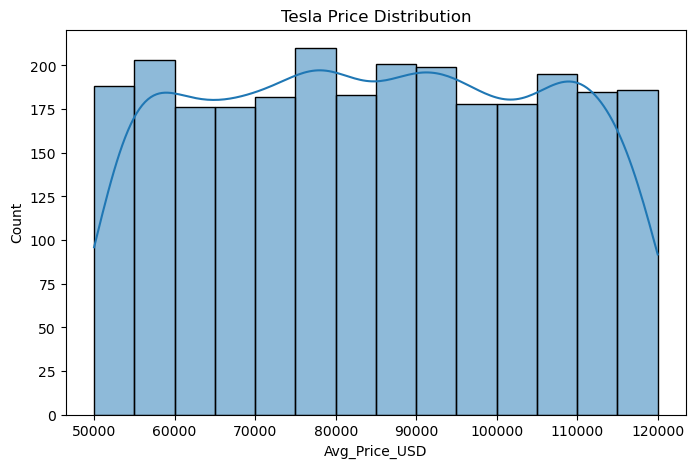

In [80]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['Avg_Price_USD'],
    kde=True
)

plt.title("Tesla Price Distribution")
plt.show()

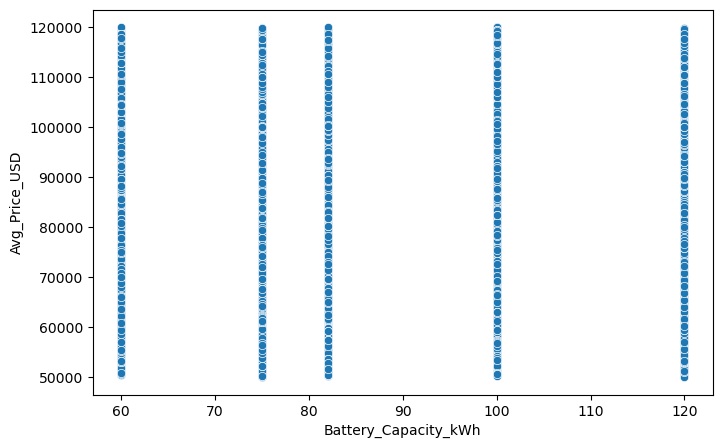

In [81]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x='Battery_Capacity_kWh',
    y='Avg_Price_USD',
    data=df
)

plt.show()

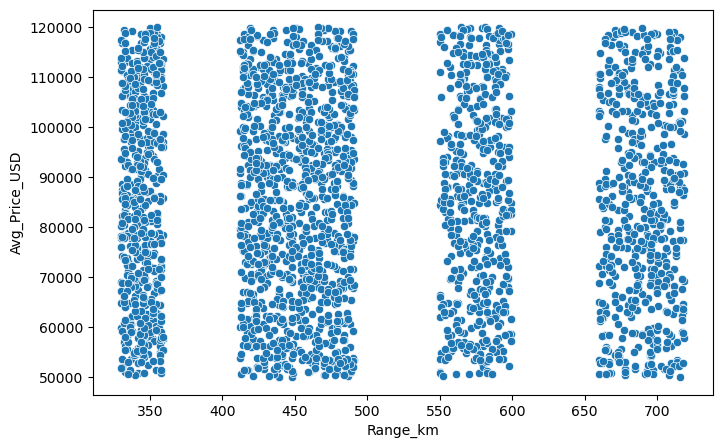

In [82]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x='Range_km',
    y='Avg_Price_USD',
    data=df
)

plt.show()

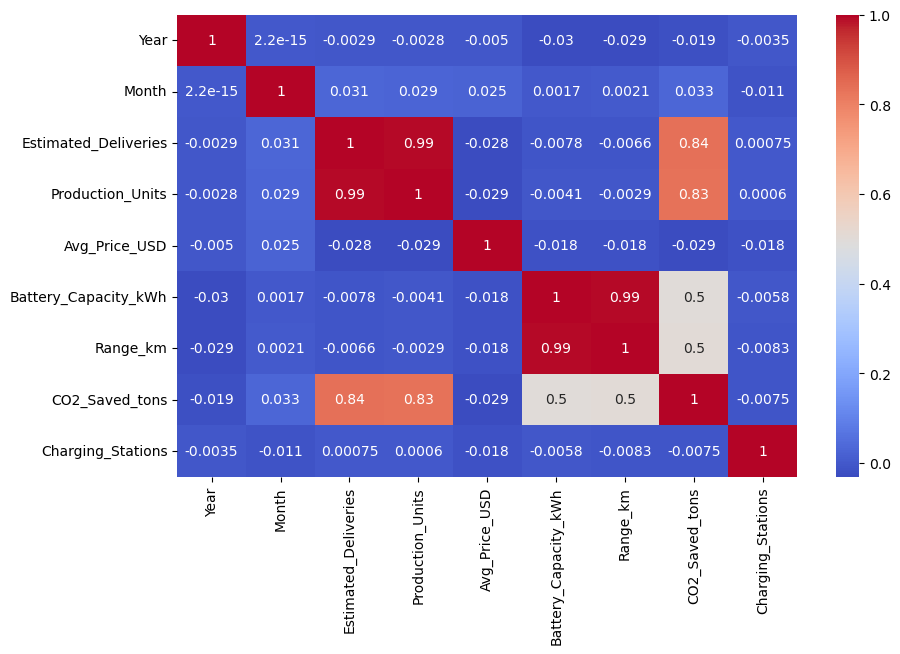

In [83]:
plt.figure(figsize=(10,6))

sns.heatmap(
    df.select_dtypes(include=np.number).corr(),
    annot=True,
    cmap='coolwarm'
)

plt.show()


In [84]:
df['Date'] = pd.to_datetime(
    df['Year'].astype(str)
    + "-"
    + df['Month'].astype(str)
)

In [85]:
df = df.sort_values('Date')

In [86]:
df['Price_Lag_1'] = (
    df['Avg_Price_USD']
    .shift(1)
)

In [87]:
df['Rolling_Mean_3'] = (
    df['Avg_Price_USD']
    .rolling(3)
    .mean()
)

In [88]:
df['Price_Per_Range'] = (
    df['Avg_Price_USD']
    /
    df['Range_km']
)

In [89]:
df.dropna(inplace=True)

In [91]:
categorical_cols = [
    'Region',
    'Model',
    'Source_Type'
]

In [92]:
df = pd.get_dummies(
    df,
    columns=categorical_cols,
    drop_first=True
)

In [93]:
print(df.columns)

Index(['Year', 'Month', 'Estimated_Deliveries', 'Production_Units',
       'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons',
       'Charging_Stations', 'Date', 'Price_Lag_1', 'Rolling_Mean_3',
       'Price_Per_Range', 'Region_Europe', 'Region_Middle East',
       'Region_North America', 'Model_Model 3', 'Model_Model S',
       'Model_Model X', 'Model_Model Y', 'Source_Type_Interpolated (Month)',
       'Source_Type_Official (Quarter)'],
      dtype='object')


In [94]:
X = df.drop(
    columns=['Avg_Price_USD', 'Date']
)

y = df['Avg_Price_USD']

In [96]:
df.columns.tolist()

['Year',
 'Month',
 'Estimated_Deliveries',
 'Production_Units',
 'Avg_Price_USD',
 'Battery_Capacity_kWh',
 'Range_km',
 'CO2_Saved_tons',
 'Charging_Stations',
 'Date',
 'Price_Lag_1',
 'Rolling_Mean_3',
 'Price_Per_Range',
 'Region_Europe',
 'Region_Middle East',
 'Region_North America',
 'Model_Model 3',
 'Model_Model S',
 'Model_Model X',
 'Model_Model Y',
 'Source_Type_Interpolated (Month)',
 'Source_Type_Official (Quarter)']

In [99]:
print(X.shape)
print(y.shape)

(2638, 20)
(2638,)


In [100]:
split_index = int(len(df) * 0.8)

X_train = X[:split_index]
X_test = X[split_index:]

y_train = y[:split_index]
y_test = y[split_index:]

In [102]:
print(X_train.shape)
print(X_test.shape)

(2110, 20)
(528, 20)


In [103]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [104]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(X_train_scaled, y_train)

lr_pred = lr.predict(X_test_scaled)

In [105]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

print("MAE :", mean_absolute_error(y_test, lr_pred))

print("RMSE :", np.sqrt(
    mean_squared_error(y_test, lr_pred)
))

print("R2 Score :", r2_score(y_test, lr_pred))

MAE : 4745.389442031849
RMSE : 5996.139743286245
R2 Score : 0.9100568853032002


In [106]:
from sklearn.linear_model import Ridge

ridge = Ridge(alpha=1)

ridge.fit(X_train_scaled, y_train)

ridge_pred = ridge.predict(X_test_scaled)

print(
    "Ridge R2:",
    r2_score(y_test, ridge_pred)
)

Ridge R2: 0.9100976303045396


In [107]:
from sklearn.linear_model import Lasso

lasso = Lasso(alpha=0.1)

lasso.fit(X_train_scaled, y_train)

lasso_pred = lasso.predict(X_test_scaled)

print(
    "Lasso R2:",
    r2_score(y_test, lasso_pred)
)

Lasso R2: 0.9100596937956645


In [108]:
cv_scores = cross_val_score(
    ridge,
    X_train_scaled,
    y_train,
    cv=5,
    scoring='r2'
)

print(cv_scores)

print("Average CV Score:",
      cv_scores.mean())

[0.90482249 0.92076448 0.91411892 0.89107611 0.91145248]
Average CV Score: 0.9084468975666578


In [110]:
params = {
    'alpha': [
        0.01,
        0.1,
        1,
        10,
        100
    ]
}

In [111]:
grid = GridSearchCV(
    Ridge(),
    params,
    cv=5
)

grid.fit(
    X_train_scaled,
    y_train
)

print(grid.best_params_)
print(grid.best_score_)

{'alpha': 0.1}
0.9084547448023207


In [112]:
pipeline = Pipeline([
    ('scaler',
     StandardScaler()),

    ('model',
     Ridge(alpha=1))
])

In [113]:
pipeline.fit(
    X_train,
    y_train
)

Pipeline(steps=[('scaler', StandardScaler()), ('model', Ridge(alpha=1))])

In [114]:
pipeline.predict(
    X_test
)

array([131976.35933497,  98710.35691563, 131990.04939335,  85425.35935246,
        80965.08026987, 106879.32621071,  94976.70421695,  58734.30139335,
       106623.55739228,  65160.44177472, 137353.77708335,  70949.43428105,
        85282.00868341,  67821.95829162,  89180.99042594,  93395.57761885,
        73786.22081237,  84934.93254622, 104470.81758029,  69151.78311516,
       106971.21493529, 104426.58654298,  86363.37033774,  79168.75620382,
       102717.13521309,  60278.61536835,  88694.34499944,  63806.77223778,
       110815.38941192,  68468.68973157,  54480.62748074,  74659.40813032,
        84536.65864268,  71034.54845264,  75145.56688949,  67596.20072333,
        53778.37921211,  62577.35368403, 103266.42739412,  84418.28687397,
        74724.19495435, 101360.04184239,  96912.90718527,  63287.86816032,
        84679.55963533,  71521.58375498,  57570.96475746, 101555.84578687,
        82694.52469639,  93687.1912605 ,  67088.96930496,  66253.32308097,
        75275.0060538 ,  

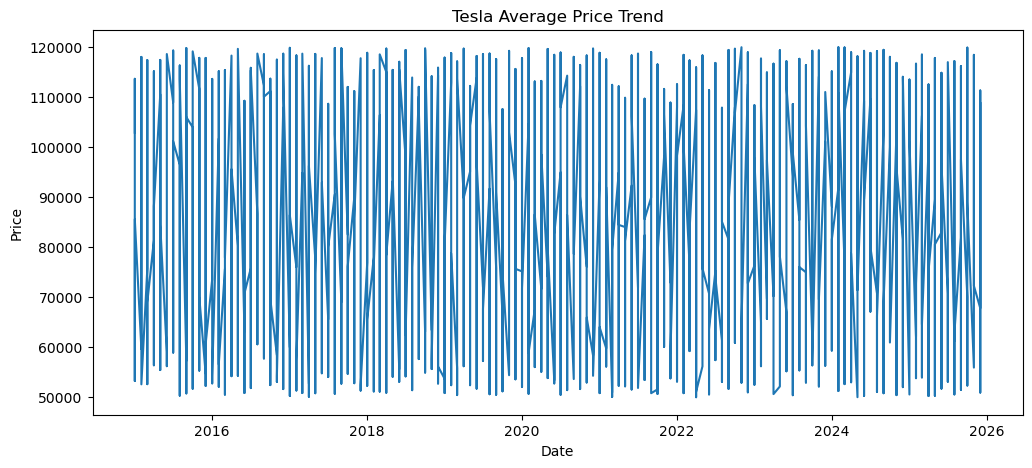

In [115]:
plt.figure(figsize=(12,5))

plt.plot(
    df['Date'],
    df['Avg_Price_USD']
)

plt.title(
    "Tesla Average Price Trend"
)

plt.xlabel("Date")
plt.ylabel("Price")
plt.show()

In [116]:
result = adfuller(
    df['Avg_Price_USD']
)

print("ADF Statistic:",
      result[0])

print("P-value:",
      result[1])

ADF Statistic: -50.286922572725224
P-value: 0.0


In [117]:
future_prices = []

last_price = (
    df['Avg_Price_USD']
    .iloc[-1]
)

for i in range(6):

    forecast_price = (
        last_price * 1.02
    )

    future_prices.append(
        forecast_price
    )

    last_price = forecast_price

print(future_prices)

[110965.9734, 113185.292868, 115448.99872536001, 117757.97869986722, 120113.13827386456, 122515.40103934186]
